# The Jacobi–Anger Expansion

The **Jacobi–Anger expansion** is a classical mathematical identity that expresses complex exponentials as infinite series of Bessel functions and Chebyshev polynomials. In quantum computing it plays a central role: it is the tool that lets us approximate the time-evolution operator $e^{-iHt}$ as a polynomial in $H$, which is the bridge that makes block-encoding-based Hamiltonian simulation possible.

This tutorial covers the expansion formulas, their Chebyshev polynomial form, and how the required polynomial degree scales with the evolution time $t$ and the target approximation error $\epsilon$. For the three quantum algorithms that build on this expansion, see:
- [Hamiltonian Simulation with GQSP](https://github.com/Classiq/classiq-library/blob/main/algorithms/hamiltonian_simulation/hamiltonian_simulation_with_block_encoding/hamiltonian_simulation_gqsp.ipynb)
- [Hamiltonian Simulation with QSVT](https://github.com/Classiq/classiq-library/blob/main/algorithms/hamiltonian_simulation/hamiltonian_simulation_with_block_encoding/hamiltonian_simulation_qsvt.ipynb)
- [Hamiltonian Simulation with Qubitization](https://github.com/Classiq/classiq-library/blob/main/algorithms/hamiltonian_simulation/hamiltonian_simulation_with_block_encoding/hamiltonian_simulation_qubitization.ipynb)

## The Expansion

The most general form of the Jacobi–Anger expansion [<a href="#ref-jawiki">1</a>] gives:
$$
e^{it\cos(x)} = \sum_{k=-\infty}^{\infty} i^k J_{k}(t)\, e^{ikx}, \qquad (1)
$$
$$
e^{it\sin(x)} = \sum_{k=-\infty}^{\infty} J_{k}(t)\, e^{ikx}, \qquad (2)
$$
from which we can derive Chebyshev polynomial series for the real-valued functions:
$$
\cos(xt) = J_0(t) + 2\sum_{k=1}^{d/2} (-1)^k J_{2k}(t)\, T_{2k}(x), \qquad (3)
$$
$$
\sin(xt) = 2\sum_{k=0}^{d/2} (-1)^k J_{2k+1}(t)\, T_{2k+1}(x), \qquad (4)
$$
where $J_k(x)$ is the Bessel function of the first kind of order $k$, and $T_k(x)$ is the Chebyshev polynomial of order $k$.

Eq. (1) is directly used in the [GQSP method](https://github.com/Classiq/classiq-library/blob/main/algorithms/hamiltonian_simulation/hamiltonian_simulation_with_block_encoding/hamiltonian_simulation_gqsp.ipynb) (applied to the walk operator). Eqs. (3)–(4) are used by both the [QSVT method](https://github.com/Classiq/classiq-library/blob/main/algorithms/hamiltonian_simulation/hamiltonian_simulation_with_block_encoding/hamiltonian_simulation_qsvt.ipynb) and the [Qubitization method](https://github.com/Classiq/classiq-library/blob/main/algorithms/hamiltonian_simulation/hamiltonian_simulation_with_block_encoding/hamiltonian_simulation_qubitization.ipynb).

## Truncation and Error Bound

The infinite series in Eqs. (3) and (4) can be truncated at degree $d$, giving polynomial approximations of $\cos(xt)$ and $\sin(xt)$. The required degree for a target approximation error $\epsilon$ and evolution time $t$ is:
$$
d = O\!\left(t + \frac{\log(1/\epsilon)}{\log\!\Big(e+\frac{\log(1/\epsilon)}{t}\Big)}\right). \qquad (5)
$$
This scaling, linear in $t$ and logarithmic in $1/\epsilon$, is optimal: it matches the quantum query complexity lower bound for Hamiltonian simulation [<a href="#ref-grand">2</a>]. This is one of the key reasons the block-encoding family of algorithms is asymptotically optimal.

Classiq's QSP application includes all 5 formulas above. Next we demonstrate the approximation for a given evolution time $t$ and error $\epsilon$.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from classiq.applications.qsp.qsp import (
    poly_jacobi_anger_cos,
    poly_jacobi_anger_degree,
    poly_jacobi_anger_sin,
)

EVOLUTION_TIME = 22
EPS = 1e-7

degree = poly_jacobi_anger_degree(EPS, EVOLUTION_TIME)
print(f"Polynomial degree for t={EVOLUTION_TIME}, ε={EPS}: d = {degree}")

Polynomial degree for t=22, ε=1e-07: d = 40


## Approximation Quality

We can visually inspect the approximation quality for $t = 22$ and $\epsilon = 10^{-7}$:

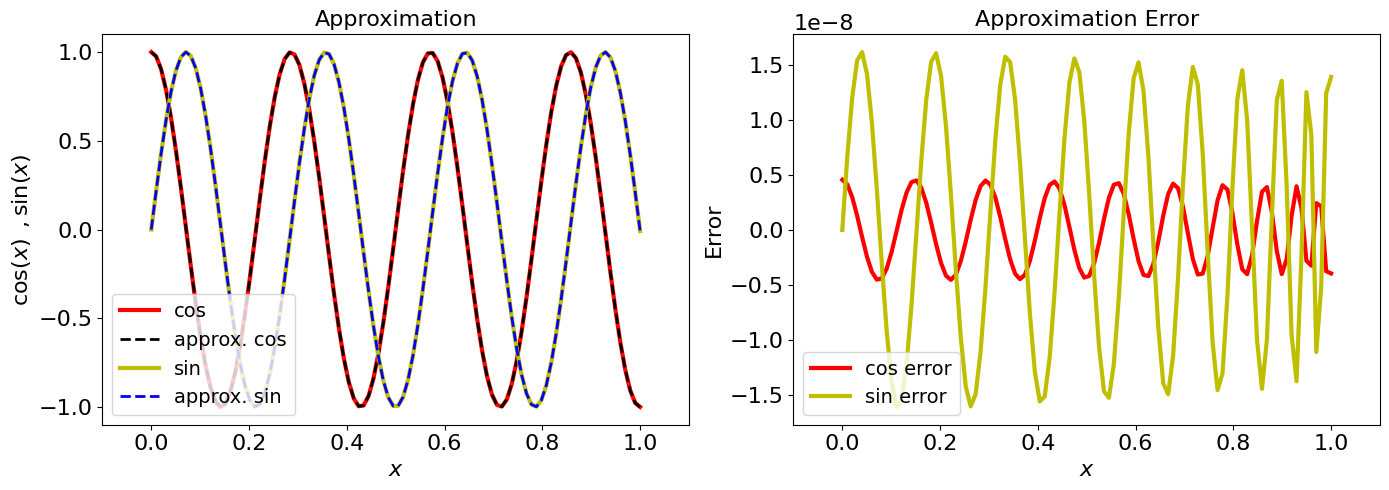

In [2]:
cos_coeffs = poly_jacobi_anger_cos(degree, EVOLUTION_TIME)
sin_coeffs = poly_jacobi_anger_sin(degree, EVOLUTION_TIME)

xs = np.linspace(0, 1, 100)
cos_approx = np.polynomial.Chebyshev(cos_coeffs)(xs)
sin_approx = np.polynomial.Chebyshev(sin_coeffs)(xs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(xs, np.cos(EVOLUTION_TIME * xs), "-r", linewidth=3, label="cos")
ax1.plot(xs, cos_approx, "--k", linewidth=2, label="approx. cos")
ax1.plot(xs, np.sin(EVOLUTION_TIME * xs), "-y", linewidth=3, label="sin")
ax1.plot(xs, sin_approx, "--b", linewidth=2, label="approx. sin")
ax1.set_ylabel(r"$\cos(x)\,\,\, , \sin(x)$", fontsize=16)
ax1.set_xlabel(r"$x$", fontsize=16)
ax1.tick_params(labelsize=16)
ax1.legend(loc="lower left", fontsize=14)
ax1.set_xlim(-0.1, 1.1)
ax1.set_title("Approximation", fontsize=16)

ax2.plot(
    xs, np.cos(EVOLUTION_TIME * xs) - cos_approx, "-r", linewidth=3, label="cos error"
)
ax2.plot(
    xs, np.sin(EVOLUTION_TIME * xs) - sin_approx, "-y", linewidth=3, label="sin error"
)
ax2.set_ylabel("Error", fontsize=16)
ax2.set_xlabel(r"$x$", fontsize=16)
ax2.tick_params(labelsize=16)
ax2.yaxis.get_offset_text().set_fontsize(16)
ax2.legend(loc="lower left", fontsize=14)
ax2.set_xlim(-0.1, 1.1)
ax2.set_title("Approximation Error", fontsize=16)

plt.tight_layout();

We can see that indeed, the approximations follow the exact formulas.

## See Also

This expansion is the mathematical foundation used by each of the three Hamiltonian simulation notebooks in this directory:

- [Hamiltonian Simulation with GQSP](https://github.com/Classiq/classiq-library/blob/main/algorithms/hamiltonian_simulation/hamiltonian_simulation_with_block_encoding/hamiltonian_simulation_gqsp.ipynb) — applies Eq. (1) as a Laurent polynomial in the walk operator $W = e^{i\arccos(H/s)}$.
- [Hamiltonian Simulation with QSVT](https://github.com/Classiq/classiq-library/blob/main/algorithms/hamiltonian_simulation/hamiltonian_simulation_with_block_encoding/hamiltonian_simulation_qsvt.ipynb) — applies Eqs. (3)–(4) as two separate QSVT polynomial transformations, combined via LCU.
- [Hamiltonian Simulation with Qubitization](https://github.com/Classiq/classiq-library/blob/main/algorithms/hamiltonian_simulation/hamiltonian_simulation_with_block_encoding/hamiltonian_simulation_qubitization.ipynb) — applies Eqs. (3)–(4) directly as Chebyshev coefficients in an LCU of walk operator powers.

## References

<a id='ref-jawiki'>[1]</a>: [Jacobi–Anger Expansion (Wikipedia)](https://en.wikipedia.org/wiki/Jacobi%E2%80%93Anger_expansion)

<a id='ref-grand'>[2]</a>: [Martyn, J. M., Rossi, Z. M., Tan, A. K., & Chuang, I. L. *Grand unification of quantum algorithms.* PRX Quantum **2**, 040203 (2021).](https://journals.aps.org/prxquantum/abstract/10.1103/PRXQuantum.2.040203)